#**Carga del dataset con el que vamos a trabajar desde PhysioNet**



In [6]:
#Primero importamos las librerías y bibliotecas necesarias para importar los archivos de audio que contiene nuestro dataset

!pip install wfdb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.8/163.8 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 61.5 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.2.3 which is incompatible.


In [7]:
# Importamos las bibliotecas necesarias para poder trabajar con los distintos conjuntos de datos procedentes de PhysioNet


import wfdb
import os

## Función que descarga los archivos desde PhysioNet

In [8]:
def descarga_archivos_physionet (ruta_drive, ruta_dataset):
  """
  Función que descarga de forma permanente el dataset de PhysioNet que indiquemos en el directorio de Google Drive especificado.

  Parámetros
  ------------
    - ruta_drive (str): Ruta en que se encuentra el dataset. Esta es relativa, es decir, no hace falta indicar el dominio.
        Ejemplo: 'challenge-2017/training'

    - ruta_dataset (str):  Ruta al directorio de Drive en el que se almacenan los archivos. Esta es completa, es necesario indicar '/content/drive/MyDrive' antes.
        Ejemplo: '/content/drive/MyDrive/dataset_ECG'


  Return
  ------------
    - None: Solo muestra por pantalla la confirmación de que los archivos se han descargado correctamente, cuando esto ha sido así. En el caso contrario, muestra un mensaje de
    error, a través de una excepción, indicando que no se ha podido completar la descarga.

  """


  from google.colab import drive                                # Importamos la biblioteca de Google Drive dentro de la función para poder conectarse a este
  drive.mount('/content/drive')                                 # Conexión del entorno de trabajo con Google Drive para almacenar los archivos

  os.makedirs(ruta_drive, exist_ok=True)                        # Creamos el directorio en el que se van a almacenar los archivos en el caso de que este no exista


  try:                                                          # Intenta descargar el set de datos desde la ruta que le hemos proporcionado
    wfdb.dl_database(ruta_dataset, dl_dir=ruta_drive)           # Realizamos la descarga de los archivos desde PhysioNet en la dirección indicada
    print (f"Los archivos se han descargado correctamente en la dirección {ruta_drive}")     # Confirmación por pantalla de que la descarga ha sido satisfactoria

  except Exception as e:                                        # Si la ruta proporcionada no es correcta, nos muestra por pantalla que no ha sido posible completar la descarga
    print (f"Error al descargar el set de datos '{ruta_dataset}' desde PhysioNet. Inténtalo de nuevo.")

### Almacenamos los datos de ECG que vamos a usar como entrenamiento para nuestra red GAN en un directorio

In [35]:
# Establecemos una ruta de Google Drive en la que guardar los archivos que descarguemos desde PhysioNet

ruta_entrenamiento = "/content/drive/MyDrive/dataset_ECG/challenge2017/entrenamiento"
ruta_physionet = "challenge-2017/training"


In [10]:
descarga_archivos_physionet (ruta_entrenamiento, ruta_physionet)

Se han truncado las últimas 5000 líneas del flujo de salida.
Generating list of all files for: A03/A03531
Generating list of all files for: A03/A03532
Generating list of all files for: A03/A03533
Generating list of all files for: A03/A03534
Generating list of all files for: A03/A03535
Generating list of all files for: A03/A03536
Generating list of all files for: A03/A03537
Generating list of all files for: A03/A03538
Generating list of all files for: A03/A03539
Generating list of all files for: A03/A03540
Generating list of all files for: A03/A03541
Generating list of all files for: A03/A03542
Generating list of all files for: A03/A03543
Generating list of all files for: A03/A03544
Generating list of all files for: A03/A03545
Generating list of all files for: A03/A03546
Generating list of all files for: A03/A03547
Generating list of all files for: A03/A03548
Generating list of all files for: A03/A03549
Generating list of all files for: A03/A03550
Generating list of all files for: A03/A

### Almacenamos los datos de ECG que se utilizan en PhysioNet como validación en un directorio de nuestro Drive

In [10]:
# Establecemos las rutas que necesitamos para poder llevar a cabo la descarga y almacenar los archivos correspondientes, respectivamente y llamamos a la función que realiza esto.

ruta_validacion = "/content/drive/MyDrive/dataset_ECG/challenge2017/validacion"
ruta_physionet2 = "challenge-2017/validation"

descarga_archivos_physionet (ruta_validacion, ruta_physionet2)

MessageError: Error: credential propagation was unsuccessful

## Funciones para cargar los archivos descargados en el entorno de trabajo (Google Colab) para poder trabajar con ellos

In [28]:
def carga_archivos_entorno (ruta_directorio, archivos=None):

  """
  Esta función carga desde el directorio de Google Drive pasado como argumento, los archivos válidos que se listan en el parámetro 'archivos' en el caso de
  que este exista, y, en caso contrario, todos aquellos que se encuentren en dicho directorio. Todos ellos deben contar con extensión '.hea'.
  A partir de cada uno de estos, la función crea un objeto de tipo wfdb.Record con la información almacenada en formato '.hea' y '.mat' para cada uno de ellos, utilizando
  para ello la biblioteca WFDB.
  Estos archivos wfdb.Record son almacenados en un diccionario, que va a ser el Return de la función, para poder ser visualizados o trabajar con ellos una vez recuperados.

  Parámetros
  -------------
    - ruta_directorio (str): Ruta del directorio de Google Drive en el que se encuentran los archivos que queremos cargar en nuestro entorno de trabajo.
        Ejemplo: '/content/drive/MyDrive/dataset_ECG_2017'

    - archivos= None (list): Lista con los nombres de los archivos que queremos cargar en formato '.hea', en el caso de que solo queramos cargar una parte de los archivos del directorio,
    no la totalidad de estos.
        Ejemplo: ['A00291.hea', 'A00483.hea']


  Return
  -------------
    - ecg_cargados (dict): Diccionario en el que se encuentran los objetos tipo wfdb.Record creados a partir de cada registro, indexados por el nombre de estos, sin extensión.
      Ejemplo: {'A00291': wfdb.Record}

  """
  from google.colab import drive
  drive.mount('/content/drive')                                              # Nos conectamos al Drive para poder recuperar los archivos desde su ubicación en Drive

  ecg_cargados = {}                                                          # Diccionario vacío, en el que vamos a almacenar los objetos tipo wfdb.Record generados
  if archivos and isinstance(archivos, list):                                                               # Comprueba si se ha pasado el argumento "archivos" para entrar en el bucle
    for i in archivos:                                                       # Recorremos la lista que contiene los nombres de los archivos '.hea' que queremos cargar
      if i.endswith('.hea'):                                                 # Comprobamos que los archivos presentan la extensión adecuada ('.hea')
        id = i.replace('.hea', '')                                           # Eliminamos la extensión del nombre del archivo, para establecer la ruta de carga
        nombre, record = proceso_interno_carga (ruta_directorio, id)         # Llamamos a la función que va a realizar la carga de los archivos en sí misma
        if record is not None:                                               # Comprueba que el registro indicado se ha cargado correctamente en el entorno de trabajo
          ecg_cargados[nombre] = record                                      # Almacena el objeto que acaba de crear en el diccionario 'ecg_cargados'

      else:                                                                  # Si el archivo no tiene la extensión adecuada ('.hea'), se imprime el siguiente error por pantalla
        print (f"El archivo {i} no es un archivo '.hea', por lo que no es válido. Inténtalo de nuevo.")

  else:                                                                      # Si no existe el argumento "archivos" se realiza la carga de todos los archivos presentes en el directorio
    for e in os.listdir(ruta_directorio):                                    # Se van a recorrer todos los registros del directorio para proceder a su carga de forma individual
      if e.endswith('.hea'):                                                 # Se comprueba que el archivo sea del tipo '.hea'
        id = e.replace('.hea', '')                                           # Se elimina la extensión del nombre del archivo, para establecer la ruta de carga
        nombre, record = proceso_interno_carga (ruta_directorio, id)         # Llamamos a la función que va a realizar la carga del archivo ECG en sí misma
        if record is not None:                                               # Comprueba si la carga ha sido correcta
          ecg_cargados[nombre] = record                                      # Almacena los datos que acaba de cargar en el diccionario, indexados por el nombre del registro



  return ecg_cargados                                                        # Devuelve el diccionario con los archivos wfdb.Record que han sido creados


In [40]:
def proceso_interno_carga (ruta_directorio, nombre_archivo):

  """
  Esta función lleva a cabo la carga en sí misma del archivo pasado como argumento en el entorno de trabajo desde el que se invoca. Para ello crea un objeto de tipo wfdb.Record
  combinando los datos almacenados tanto en formato '.hea' como '.mat' para ese registro y es el que devuelvecuando se llama a esta función.

  Parámetros
  --------------
    - ruta_directorio (str): Directorio de Google Drive en el que se encuentran los archivos con los que queremos trabajar en el entorno de trabajo
        Ejemplo: '/content/drive/MyDrive/dataset_ECG/train'

    - nombre_archivo(str): Nombre con el que se almacena el ECG que va a ser cargado para poder trabajar con él, sin extensión
        Ejemplo: "A00037"

  Return
  --------------
    - nombre_archivo (str): Nombre del archivo que se ha cargado, sin extensión

    - record --> wfdb.Record o None: Si se ha podido cargar el archivo, la función devuelve el objeto de tipo Record, y en caso contrario no devuelve nada

  """

  ruta_completa_archivo = os.path.join(ruta_directorio, nombre_archivo)           # Ruta completa en la que se encuentra el archivo a cargar

  try:                                                                            # Intenta hacer la carga de los datos desde Google Drive
    record = wfdb.rdrecord(ruta_completa_archivo)                                 # Creación del objeto wfdb.Record a partir de los archivos '.hea' y '.mat' de dicho registro
    print(f"Se ha cargado el archivo {nombre_archivo} correctamente.")            # Confirmación por pantalla de que la carga ha sido satisfactoria
    return nombre_archivo, record                                                 # Devolución del identificador del archivo cargado y el objeto wfdb.Record que ha creado

  except Exception as e:                                                          # Si la carga no ha sido satisfactoria, muestra un mensaje de error por pantalla
    print(f"Error al cargar el archivo {nombre_archivo}: {e}. Inténtalo de nuevo.")
    return nombre_archivo, None                                                   # Devolución del nombre del archivo que no ha sido posible cargar, y de un objeto vacío





In [33]:
ecg_validacion = carga_archivos_entorno (ruta_validacion)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Se ha cargado el archivo A00039 correctamente.
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Se ha cargado el archivo A00001 correctamente.
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Se ha cargado el archivo A00040 correctamente.
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Se ha cargado el archivo A00002 correctamente.
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Se ha cargado el archivo A00041 correc

In [39]:
# Para cargar los datos de entrenamiento es necesario especificar la ruta completa, hasta que la función encuentre archivos con la extensión '.hea'.

ruta_entrenamiento_A00 = "/content/drive/MyDrive/dataset_ECG/challenge2017/entrenamiento/A00"

ecg_entrenamiento_A00 = carga_archivos_entorno (ruta_entrenamiento_A00)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Se ha cargado el archivo A00500 correctamente.
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Se ha cargado el archivo A00501 correctamente.
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Se ha cargado el archivo A00502 correctamente.
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Se ha cargado el archivo A00503 correctamente.
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Se ha cargado el archivo A00504 correc

In [37]:
ruta_entrenamiento_A01 = "/content/drive/MyDrive/dataset_ECG/challenge2017/entrenamiento/A01"

ecg_entrenamiento_A01 = carga_archivos_entorno (ruta_entrenamiento_A01)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Se ha cargado el archivo A00039 correctamente.
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Se ha cargado el archivo A00001 correctamente.
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Se ha cargado el archivo A00040 correctamente.
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Se ha cargado el archivo A00002 correctamente.
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Se ha cargado el archivo A00041 correc

KeyboardInterrupt: 

In [ ]:
ruta_entrenamiento_A02 = "/content/drive/MyDrive/dataset_ECG/challenge2017/entrenamiento/A02"

ecg_entrenamiento_A02 = carga_archivos_entorno (ruta_entrenamiento_A02)

In [ ]:
ruta_entrenamiento_A03 = "/content/drive/MyDrive/dataset_ECG/challenge2017/entrenamiento/A03"

ecg_entrenamiento_A03 = carga_archivos_entorno (ruta_entrenamiento_A03)

In [ ]:
ruta_entrenamiento_A04 = "/content/drive/MyDrive/dataset_ECG/challenge2017/entrenamiento/A04"

ecg_entrenamiento_A04 = carga_archivos_entorno (ruta_entrenamiento_A04)

In [ ]:
ruta_entrenamiento_A05 = "/content/drive/MyDrive/dataset_ECG/challenge2017/entrenamiento/A05"

ecg_entrenamiento_A05 = carga_archivos_entorno (ruta_entrenamiento_A05)

In [ ]:
ruta_entrenamiento_A06 = "/content/drive/MyDrive/dataset_ECG/challenge2017/entrenamiento/A06"

ecg_entrenamiento_A06 = carga_archivos_entorno (ruta_entrenamiento_A06)

In [ ]:
ruta_entrenamiento_A07 = "/content/drive/MyDrive/dataset_ECG/challenge2017/entrenamiento/A07"

ecg_entrenamiento_A07 = carga_archivos_entorno (ruta_entrenamiento_A07)

In [ ]:
ruta_entrenamiento_A08 = "/content/drive/MyDrive/dataset_ECG/challenge2017/entrenamiento/A08"

ecg_entrenamiento_A08 = carga_archivos_entorno (ruta_entrenamiento_A08)

# ** Representación de los ECG del dataset**

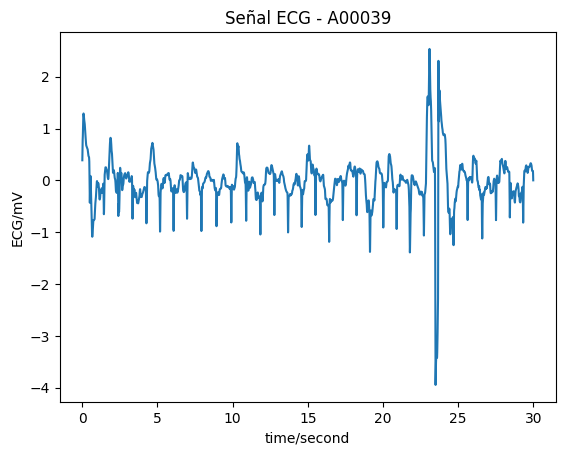

In [15]:
registro_base = archivos_drive[0].replace('.hea', '')
ruta_completa = os.path.join(ruta_validacion, registro_base)

record = wfdb.rdrecord(ruta_completa)
wfdb.plot_wfdb(record=record, title=f"Señal ECG - {registro_base}")

In [ ]:
def carga_archivos_drive (ruta_drive):



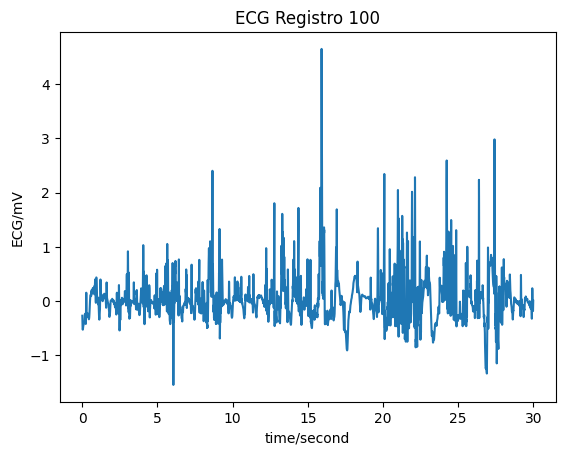

In [19]:
# Visualizar una señal mediante WFDB

record = wfdb.rdrecord('challenge2017/validation/A04805')

# Graficar señal
wfdb.plot_wfdb(record=record, title='ECG Registro 100')


